# Calculus for Machine Learning

## Why Calculus?

Machine Learning = adjust parameters to minimize error.

**Calculus** tells you:
- **Which direction** to adjust (derivative = slope)
- **How fast** things are changing (rate of change)
- **What's the best** value (find minimum/maximum)

### The Big Picture

| Concept | Think of it as | Used in |
|---------|---------------|----------|
| Derivative | Slope of a curve at one point | How much to adjust weights |
| Partial Derivative | Slope when changing one variable only | Each weight independently |
| Gradient | All partial derivatives as a vector | Gradient descent |
| Chain Rule | Derivative of composition | Backpropagation |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

---
## 1. What Is a Derivative? (Slope at a Point)

Imagine you're walking on a hilly road. The **derivative** at your current position tells you:
- **Positive** = going uphill
- **Negative** = going downhill
- **Zero** = flat (you're at the top of a hill or bottom of a valley)

### Formula: slope = (change in y) / (change in x) as change gets tiny

For `f(x) = x^2`: the derivative is `f'(x) = 2x`

This means:
- At x=1, slope = 2 (going up)
- At x=0, slope = 0 (flat, bottom!)
- At x=-1, slope = -2 (going down from left)

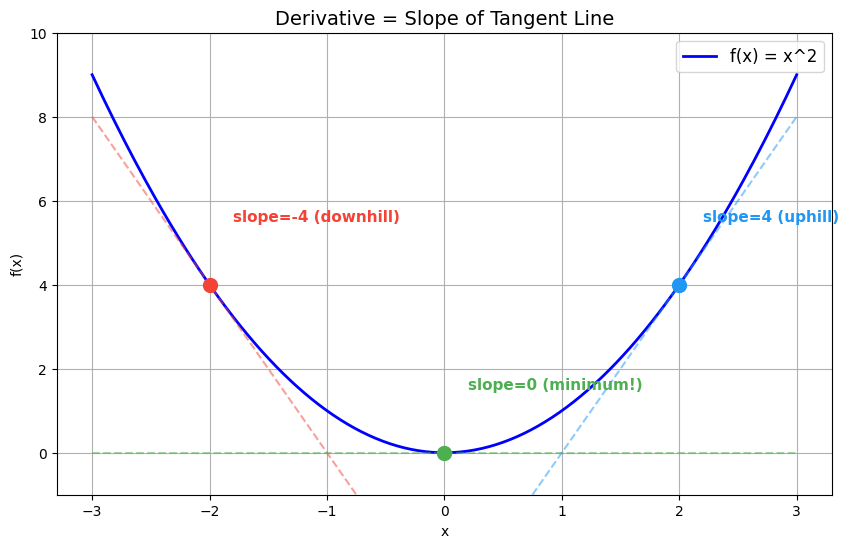

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-3, 3, 200)
y = x**2

ax.plot(x, y, 'b-', linewidth=2, label='f(x) = x^2')

tangent_points = [(-2, 'slope=-4 (downhill)', '#F44336'),
                  (0,  'slope=0 (minimum!)', '#4CAF50'),
                  (2,  'slope=4 (uphill)', '#2196F3')]

for xp, label, color in tangent_points:
    yp = xp**2
    slope = 2 * xp
    tangent_y = slope * (x - xp) + yp
    ax.plot(x, tangent_y, '--', color=color, alpha=0.5, linewidth=1.5)
    ax.plot(xp, yp, 'o', color=color, markersize=10, zorder=5)
    ax.text(xp + 0.2, yp + 1.5, label, fontsize=11, color=color, fontweight='bold')

ax.set_title('Derivative = Slope of Tangent Line', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(fontsize=12)
ax.set_ylim(-1, 10)
plt.show()

---
## 2. Common Derivatives (Cheat Sheet)

| Function f(x) | Derivative f'(x) | Intuition |
|---------------|-------------------|----------|
| `c` (constant) | `0` | Flat line, no change |
| `x` | `1` | 45 degree line, constant slope |
| `x^2` | `2x` | Slope increases as x grows |
| `x^n` | `n*x^(n-1)` | Power rule |
| `e^x` | `e^x` | Exponential: slope = value |
| `ln(x)` | `1/x` | Log grows slower and slower |
| `sin(x)` | `cos(x)` | Sine/Cosine are connected |

### Numerical Derivative (No formulas needed!)

You can approximate any derivative by:
```
f'(x) ≈ (f(x + h) - f(x)) / h    where h is very small
```

In [3]:
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

def f(x):
    return x**2

def f_prime(x):
    return 2 * x

test_points = [-3, -1, 0, 1, 2, 3]
print("f(x) = x^2,  f'(x) = 2x\n")
print(f"{'x':>5} | {'Exact':>10} | {'Numerical':>10} | {'Match':>6}")
print("-" * 42)
for x in test_points:
    exact = f_prime(x)
    approx = numerical_derivative(f, x)
    print(f"{x:5.1f} | {exact:10.4f} | {approx:10.4f} | {np.isclose(exact, approx)}")

print("\nNumerical derivative works for ANY function!")
print("No need to memorize formulas - the computer does it.")

f(x) = x^2,  f'(x) = 2x

    x |      Exact |  Numerical |  Match
------------------------------------------
 -3.0 |    -6.0000 |    -6.0000 | True
 -1.0 |    -2.0000 |    -2.0000 | True
  0.0 |     0.0000 |     0.0000 | True
  1.0 |     2.0000 |     2.0000 | True
  2.0 |     4.0000 |     4.0000 | True
  3.0 |     6.0000 |     6.0000 | True

Numerical derivative works for ANY function!
No need to memorize formulas - the computer does it.


---
## 3. Finding the Minimum (Why ML Cares About Derivatives)

### Key insight: When f'(x) = 0, you're at a minimum or maximum.

In ML, we want to **minimize error** (loss function).

### Gradient Descent: Follow the slope downhill
```
x_new = x_old - learning_rate * f'(x_old)
```
- If slope is positive (going up) → move left (decrease x)
- If slope is negative (going down) → move right (increase x)
- Either way, you move toward the minimum!

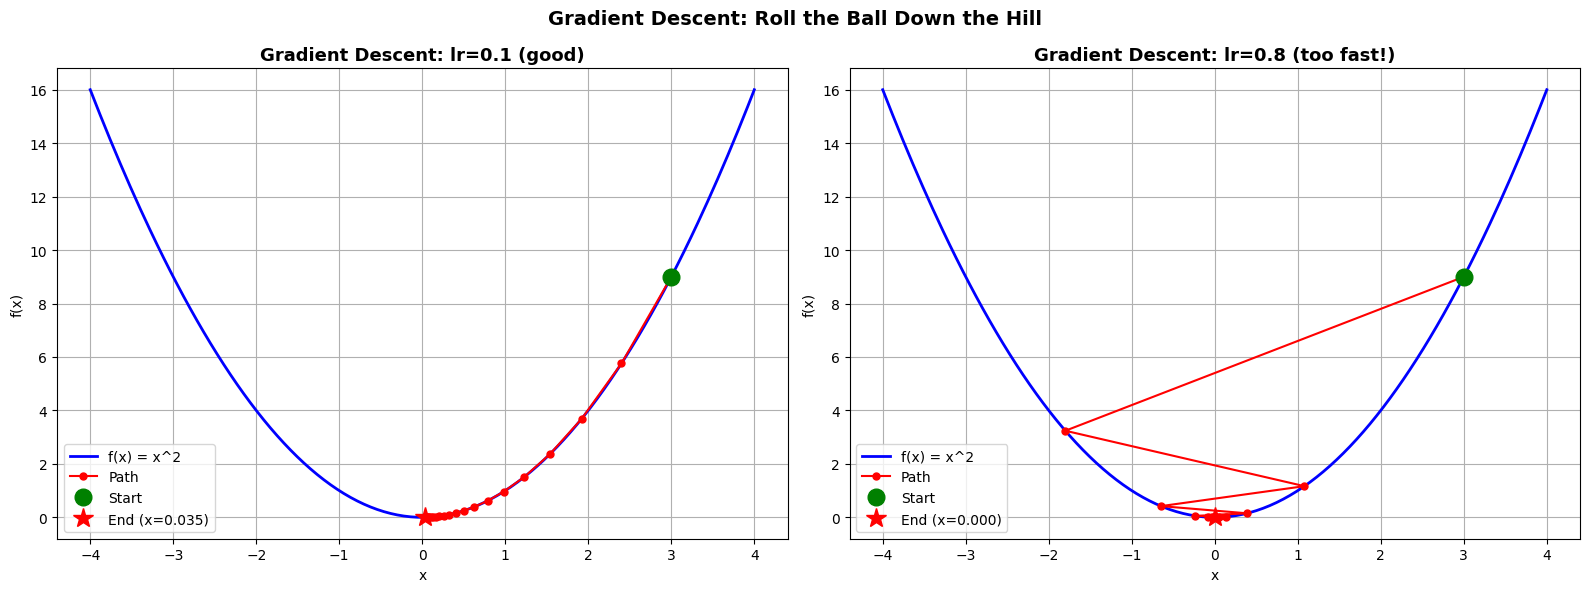

Think of it as placing a ball on the curve.
The ball rolls downhill until it reaches the bottom.
learning_rate = how big each step is.
Too small = slow. Too big = bounces around!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

f = lambda x: x**2
f_prime = lambda x: 2*x

for ax, (start, lr, title) in zip(axes, [
    (3.0, 0.1, 'Gradient Descent: lr=0.1 (good)'),
    (3.0, 0.8, 'Gradient Descent: lr=0.8 (too fast!)'),
]):
    x = np.linspace(-4, 4, 200)
    ax.plot(x, f(x), 'b-', linewidth=2, label='f(x) = x^2')

    x_curr = start
    path = [x_curr]
    for _ in range(20):
        grad = f_prime(x_curr)
        x_curr = x_curr - lr * grad
        path.append(x_curr)

    path = np.array(path)
    ax.plot(path, f(path), 'ro-', markersize=5, linewidth=1.5, label='Path')
    ax.plot(path[0], f(path[0]), 'go', markersize=12, label='Start')
    ax.plot(path[-1], f(path[-1]), 'r*', markersize=15, label=f'End (x={path[-1]:.3f})')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')

plt.suptitle('Gradient Descent: Roll the Ball Down the Hill', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Think of it as placing a ball on the curve.")
print("The ball rolls downhill until it reaches the bottom.")
print("learning_rate = how big each step is.")
print("Too small = slow. Too big = bounces around!")

---
## 4. Partial Derivatives (Multi-Variable)

Real ML models have **many** parameters. Each one has its own slope.

### Partial Derivative = change in output when you change ONE variable, keeping others fixed

For `f(x, y) = x^2 + y^2`:
- `df/dx = 2x` (how f changes when only x changes)
- `df/dy = 2y` (how f changes when only y changes)

The **gradient** = vector of all partial derivatives:
```
gradient = [df/dx, df/dy] = [2x, 2y]
```
The gradient **points uphill**. So to go downhill, you go OPPOSITE to the gradient.

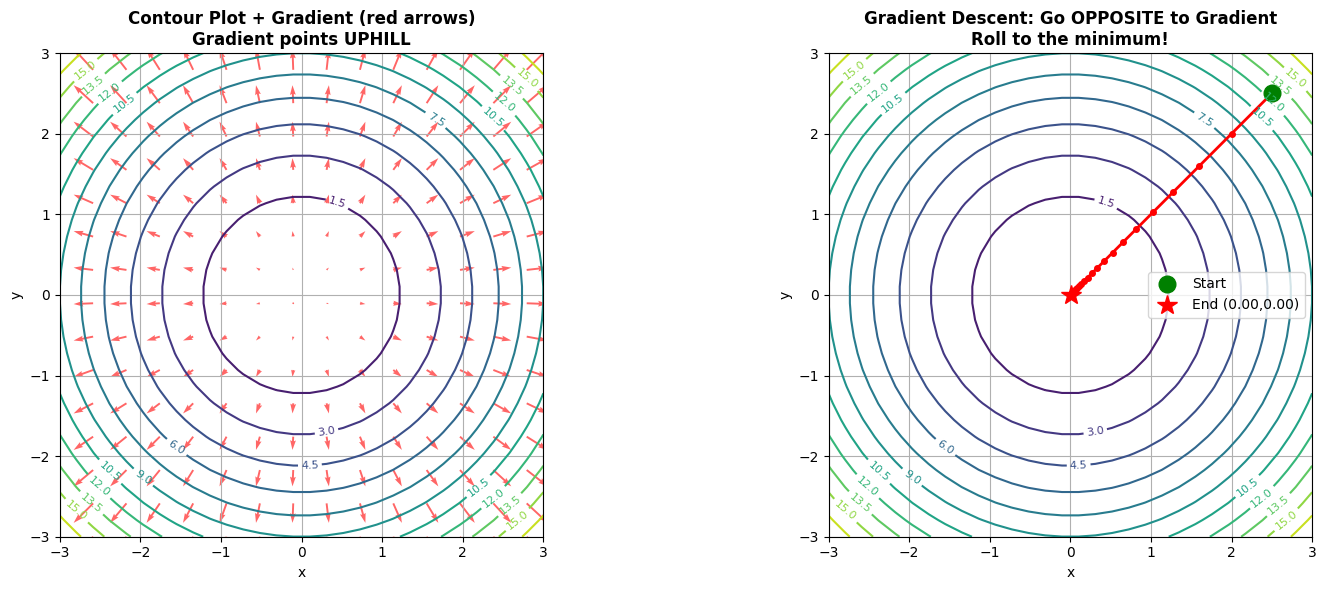

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

f = lambda x, y: x**2 + y**2

x_grid = np.linspace(-3, 3, 30)
y_grid = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

ax = axes[0]
contour = ax.contour(X, Y, Z, levels=15, cmap='viridis')
ax.clabel(contour, inline=True, fontsize=8)

skip = 2
dx = 2 * X[::skip, ::skip]
dy = 2 * Y[::skip, ::skip]
ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], dx, dy, color='red', alpha=0.6)
ax.set_title('Contour Plot + Gradient (red arrows)\nGradient points UPHILL', fontsize=12, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

ax = axes[1]
contour = ax.contour(X, Y, Z, levels=15, cmap='viridis')
ax.clabel(contour, inline=True, fontsize=8)

path_x, path_y = [2.5], [2.5]
lr = 0.1
for _ in range(30):
    gx = 2 * path_x[-1]
    gy = 2 * path_y[-1]
    path_x.append(path_x[-1] - lr * gx)
    path_y.append(path_y[-1] - lr * gy)

ax.plot(path_x, path_y, 'r.-', linewidth=2, markersize=8)
ax.plot(path_x[0], path_y[0], 'go', markersize=12, label='Start')
ax.plot(path_x[-1], path_y[-1], 'r*', markersize=15, label=f'End ({path_x[-1]:.2f},{path_y[-1]:.2f})')
ax.set_title('Gradient Descent: Go OPPOSITE to Gradient\nRoll to the minimum!', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 5. The Chain Rule (How Neural Networks Learn)

### The most important rule in all of deep learning.

When functions are composed: `z = f(g(x))`

```
dz/dx = dz/dg * dg/dx
```

### Intuition: A factory assembly line
```
x → [Machine g] → g(x) → [Machine f] → f(g(x))
```
If you want to know how changing x affects the final output:
- How much does g change when x changes? (dg/dx)
- How much does output change when g changes? (df/dg)
- Multiply them! (chain rule)

### In a neural network:
```
input → [Layer1] → [Layer2] → [Layer3] → output → loss
                                                    ↑
chain rule works backwards = BACKPROPAGATION
```

In [6]:
def g(x):
    return 3 * x + 1

def f(u):
    return u**2

def composed(x):
    return f(g(x))

def dg_dx(x):
    return 3

def df_du(u):
    return 2 * u

def chain_rule(x):
    u = g(x)
    return df_du(u) * dg_dx(x)

x_test = [0, 1, 2, -1]
print("Chain Rule: d/dx[f(g(x))] = f'(g(x)) * g'(x)")
print("f(u) = u^2,  g(x) = 3x + 1\n")

for x in x_test:
    u = g(x)
    print(f"x={x:2d} → g(x)={u:2d} → f(g(x))={f(u):3d} → chain={chain_rule(x):2d}")
    print(f"  Step by step: f'({u})={df_du(u)} × g'({x})={dg_dx(x)} = {chain_rule(x)}")
    print()

exact = numerical_derivative(composed, 2.0)
chain = chain_rule(2.0)
print(f"Verify at x=2: numerical={exact:.4f}, chain_rule={chain:.4f}")
print(f"Match: {np.isclose(exact, chain)}")

Chain Rule: d/dx[f(g(x))] = f'(g(x)) * g'(x)
f(u) = u^2,  g(x) = 3x + 1

x= 0 → g(x)= 1 → f(g(x))=  1 → chain= 6
  Step by step: f'(1)=2 × g'(0)=3 = 6

x= 1 → g(x)= 4 → f(g(x))= 16 → chain=24
  Step by step: f'(4)=8 × g'(1)=3 = 24

x= 2 → g(x)= 7 → f(g(x))= 49 → chain=42
  Step by step: f'(7)=14 × g'(2)=3 = 42

x=-1 → g(x)=-2 → f(g(x))=  4 → chain=-12
  Step by step: f'(-2)=-4 × g'(-1)=3 = -12

Verify at x=2: numerical=42.0000, chain_rule=42.0000
Match: True


---
## 6. Loss Functions & Gradients

### MSE (Mean Squared Error) - for regression
```
L = (1/n) * sum((predicted - actual)^2)
```

If `predicted = w * x` (simple linear model):
```
dL/dw = (2/n) * sum((w*x - y) * x)
```

This tells you which direction to adjust w to reduce error!

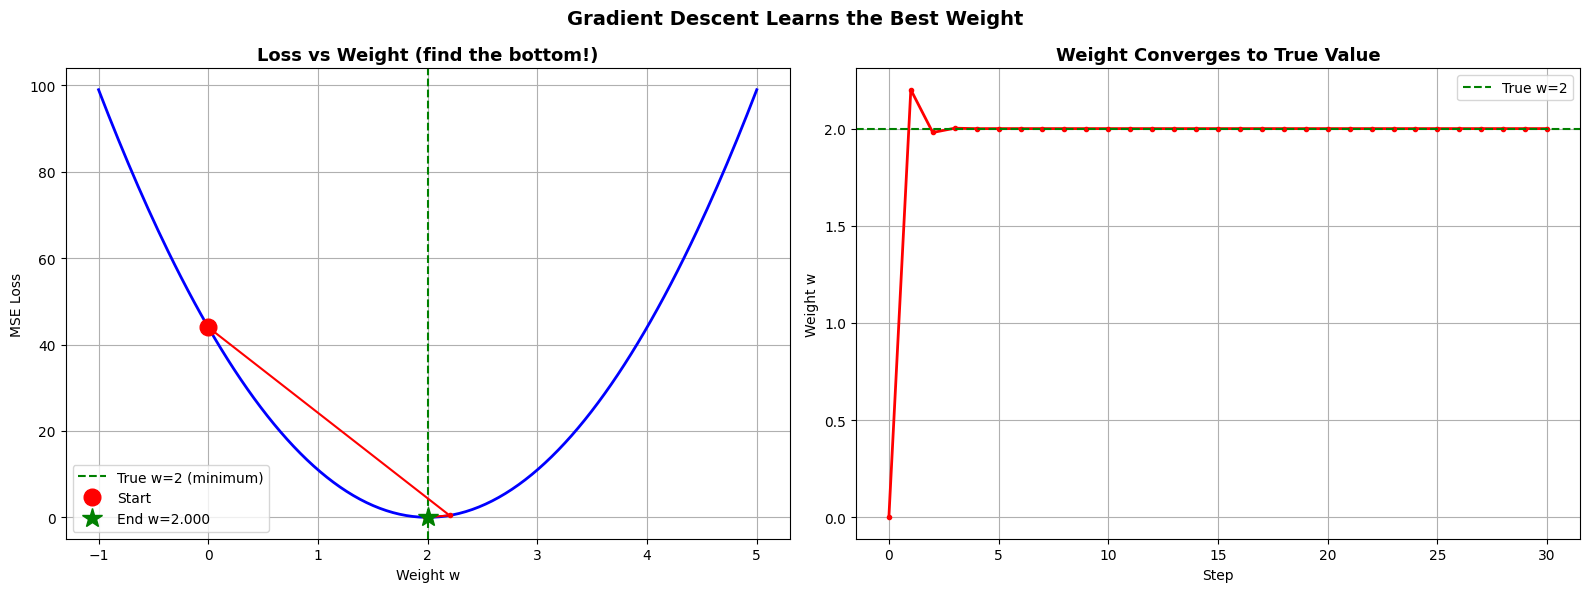

Final weight: 2.0000 (true: 2.0)
Final loss: 0.000000
The model LEARNED the correct weight from data!


In [7]:
np.random.seed(42)
x_data = np.array([1, 2, 3, 4, 5], dtype=float)
y_data = np.array([2, 4, 6, 8, 10], dtype=float)  # true: y = 2x

def mse_loss(w):
    predictions = w * x_data
    return np.mean((predictions - y_data) ** 2)

def mse_gradient(w):
    predictions = w * x_data
    return 2 * np.mean((predictions - y_data) * x_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

w_range = np.linspace(-1, 5, 200)
losses = [mse_loss(w) for w in w_range]

axes[0].plot(w_range, losses, 'b-', linewidth=2)
axes[0].axvline(x=2, color='g', linestyle='--', label='True w=2 (minimum)')
axes[0].set_title('Loss vs Weight (find the bottom!)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weight w')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

w = 0.0
lr = 0.05
history_w = [w]
history_loss = [mse_loss(w)]
for _ in range(30):
    grad = mse_gradient(w)
    w = w - lr * grad
    history_w.append(w)
    history_loss.append(mse_loss(w))

axes[0].plot(history_w, history_loss, 'r.-', linewidth=1.5, markersize=6)
axes[0].plot(history_w[0], history_loss[0], 'ro', markersize=12, label='Start')
axes[0].plot(history_w[-1], history_loss[-1], 'g*', markersize=15, label=f'End w={w:.3f}')
axes[0].legend()

axes[1].plot(history_w, 'r.-', linewidth=2, markersize=6)
axes[1].axhline(y=2, color='g', linestyle='--', label='True w=2')
axes[1].set_title('Weight Converges to True Value', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Weight w')
axes[1].legend()

plt.suptitle('Gradient Descent Learns the Best Weight', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Final weight: {w:.4f} (true: 2.0)")
print(f"Final loss: {mse_loss(w):.6f}")
print("The model LEARNED the correct weight from data!")

---
## 7. Learning Rate Visualization

The **learning rate** is the most important hyperparameter.

- **Too small**: converges very slowly
- **Good**: converges smoothly
- **Too large**: overshoots, may diverge!

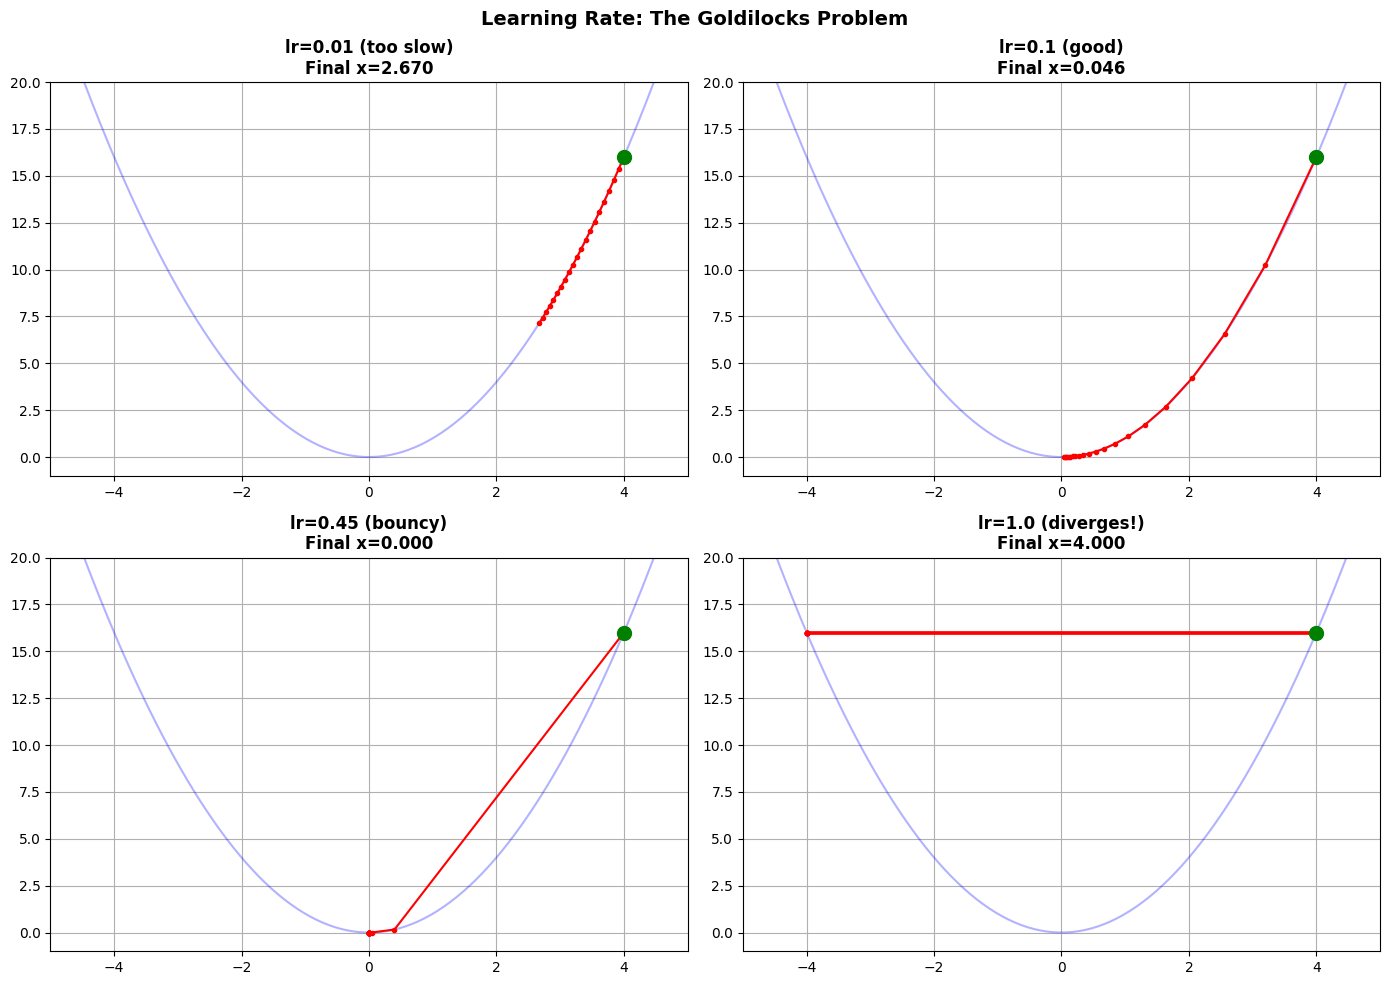

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

f = lambda x: x**2
fp = lambda x: 2*x

lrs = [(0.01, 'lr=0.01 (too slow)'),
       (0.1,  'lr=0.1 (good)'),
       (0.45, 'lr=0.45 (bouncy)'),
       (1.0,  'lr=1.0 (diverges!)')]

for ax, (lr, title) in zip(axes.flat, lrs):
    x_curve = np.linspace(-5, 5, 200)
    ax.plot(x_curve, f(x_curve), 'b-', linewidth=1.5, alpha=0.3)

    x = 4.0
    path = [x]
    for _ in range(20):
        x = x - lr * fp(x)
        path.append(x)
        if abs(x) > 10:
            break

    path = np.array(path)
    valid = np.abs(path) < 5
    ax.plot(path[valid], f(path[valid]), 'r.-', linewidth=1.5, markersize=6)
    ax.plot(path[0], f(path[0]), 'go', markersize=10)
    ax.set_title(f'{title}\nFinal x={path[-1]:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-1, 20)

plt.suptitle('Learning Rate: The Goldilocks Problem', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Summary

| Concept | Formula | ML Application |
|---------|---------|----------------|
| Derivative | `f'(x) = limit of slope` | How much to adjust one weight |
| Partial Derivative | `df/dx_i` | How much to adjust weight_i |
| Gradient | `[df/dx1, df/dx2, ...]` | All weight adjustments at once |
| Chain Rule | `dy/dx = dy/du * du/dx` | Backpropagation through layers |
| Gradient Descent | `x = x - lr * gradient` | The learning algorithm |

### The ONE thing to remember:
```
new_weight = old_weight - learning_rate * gradient_of_loss
```
This single line is how **every** neural network learns.

### Next: Probability & Statistics (`05_probability_basics.ipynb`)